<a href="https://colab.research.google.com/github/naffaziy24/anlysis-hotel-reservation/blob/main/Modul_5_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Informasi Tipe Data Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  float64
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  float64
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  float64
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  in

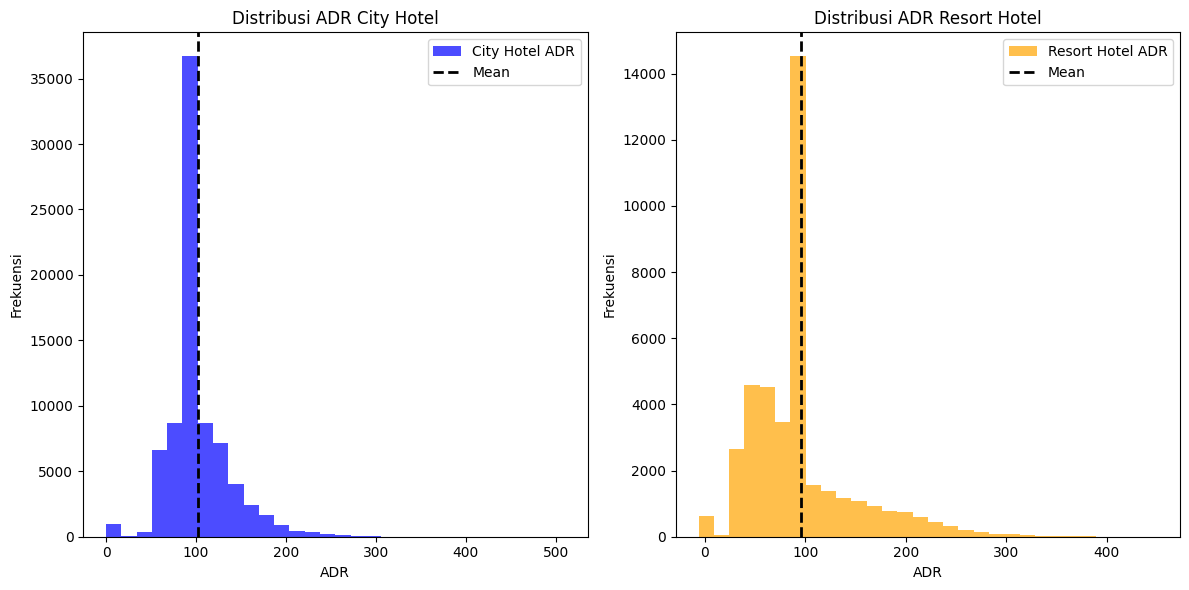


Uji Mann-Whitney Statistik: 1922100889.5
p-value: 0.0

Interpretasi hasil:
Tolak H0: Rata-rata ADR berbeda antara City Hotel dan Resort Hotel.
Sehingga jenis hotel (City Hotel atau Resort Hotel) memiliki pengaruh signifikan terhadap Rata-rata ADR.


In [ ]:
import pandas as pd
import seaborn as sns
from scipy import stats

# Mengimpor dataset
df = pd.read_csv('/content/preprocessing_hotel_data.csv')

# Menampilkan informasi awal untuk melihat tipe data
print("\nInformasi Tipe Data Awal:")
print(df.info())
# Mengecek data duplikat
duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicate_count}")
# Mengecek data kosong
missing_values = df.isnull().sum()
print("\nJumlah data kosong di setiap kolom:")
print(missing_values)

# Membuat group jenis hotel berdasarkan ADR
city_hotel_adr = df[df['hotel'] == 'City Hotel']['adr']
resort_hotel_adr = df[df['hotel'] == 'Resort Hotel']['adr']

# Menghitung rata-rata ADR untuk setiap jenis hotel
average_adr = {
    'Hotel Type': ['City Hotel', 'Resort Hotel'],
    'Average ADR': [city_hotel_adr.mean(), resort_hotel_adr.mean()]
}
# Mengubah ke dalam DataFrame
average_adr_city_resort = pd.DataFrame(average_adr)

# Menampilkan tabel rata-rata ADR
print("\nTabel Rata-rata ADR:")
print(average_adr_city_resort)

# Memeriksa distribusi normal untuk City Hotel
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(city_hotel_adr, bins=30, color='blue', alpha=0.7, label='City Hotel ADR')
plt.axvline(city_hotel_adr.mean(), color='k', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribusi ADR City Hotel')
plt.xlabel('ADR')
plt.ylabel('Frekuensi')
plt.legend()

# Memeriksa distribusi normal untuk Resort Hotel
plt.subplot(1, 2, 2)
plt.hist(resort_hotel_adr, bins=30, color='orange', alpha=0.7, label='Resort Hotel ADR')
plt.axvline(resort_hotel_adr.mean(), color='k', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribusi ADR Resort Hotel')
plt.xlabel('ADR')
plt.ylabel('Frekuensi')
plt.legend()

plt.tight_layout()
plt.show()

# Melakukan uji Mann-Whitney
statistic, p_value = stats.mannwhitneyu(city_hotel_adr, resort_hotel_adr, alternative='two-sided')

# Menampilkan hasil
print(f"\nUji Mann-Whitney Statistik: {statistic}")
print(f"p-value: {p_value}")

# Menentukan tingkat signifikansi (alpha)
alpha = 0.05

# Menginterpretasikan hasil
if p_value < alpha:
    print("\nInterpretasi hasil:")
    print("Tolak H0: Rata-rata ADR berbeda antara City Hotel dan Resort Hotel.\nSehingga jenis hotel (City Hotel atau Resort Hotel) memiliki pengaruh signifikan terhadap Rata-rata ADR.")
else:
    print("\nInterpretasi hasil:")
    print("Gagal menolak H0: Rata-rata ADR sama untuk City Hotel dan Resort Hotel.\nSehingga jenis hotel (City Hotel atau Resort Hotel) tidak memiliki pengaruh signifikan terhadap Rata-rata ADR.")
